In [1]:
!pip install qiskit
!pip install qiskit-aer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 64.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 87.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.5/49.5 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 137.9 MB/s eta 0:00:00


In [2]:
# Modern imports
import random
# import tensorflow as tf
from qiskit import QuantumCircuit, ClassicalRegister, QuantumRegister, transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector, DensityMatrix, partial_trace, Operator
from typing import List, Tuple, Dict
import matplotlib.pyplot as plt
from scipy.optimize import minimize
# from tensorflow.keras.optimizers import Adam
import numpy as np

# Fix random seed for reproducible examples (remove or change for real randomness)
random.seed(42)

# Backend simulator
backend = AerSimulator()

In [3]:
def random_bits(n: int) -> List[int]:
    return [random.randint(0, 1) for _ in range(n)]

def random_bases(n: int) -> List[int]:
    """Return 0 for Z-basis (|0>, |1>), 1 for X-basis (|+>, |->)"""
    return [random.randint(0, 1) for _ in range(n)]

def prepare_circuits_for_alice(bits: List[int], bases: List[int]) -> List[QuantumCircuit]:
    """Create one circuit per qubit encoding Alice's preparation."""
    circuits = []
    for b, basis in zip(bits, bases):
        qc = QuantumCircuit(1, 1)
        # encode bit in Z basis by applying X if bit==1
        if b == 1:
            qc.x(0)
        # if basis is X, apply H to prepare |+> / |->
        if basis == 1:
            qc.h(0)
        # leave a measurement placeholder for later (Bob or Eve will measure)
        circuits.append(qc)
    return circuits


def measure_in_basis_circuits(bases: List[int], incoming_circuits: List[QuantumCircuit]) -> List[QuantumCircuit]:
    """Given basis choices and existing single-qubit circuits (prepared qubit),
    append measurement operations for Bob (or Eve)."""
    circuits = []
    for basis, base_qc in zip(bases, incoming_circuits):
        qc = base_qc.copy()
        # if measuring in X basis, rotate with H before measuring
        if basis == 1:
            qc.h(0)
        qc.measure(0, 0)
        circuits.append(qc)
    return circuits


def run_circuits_get_bits(circuits: List[QuantumCircuit], shots: int = 1) -> List[int]:
    """Run circuits on AerSimulator in a batch and return list of measured bits (one shot per circuit).
    We assume one classical bit per circuit and shots=1 per circuit.)"""
    if not circuits:
        return []
    # transpile for backend
    t_circuits = transpile(circuits, backend=backend)
    job = backend.run(t_circuits, shots=shots)
    result = job.result()
    counts_list = [result.get_counts(i) for i in range(len(t_circuits))]
    measured = []
    for counts in counts_list:
        # counts is a dict like {'0': 1} or {'1': 1}
        # since shots=1, pick the single key
        bit = int(next(iter(counts)))
        measured.append(bit)
    return measured


def eve_intercept_resend(alice_circuits: List[QuantumCircuit], eve_bases: List[int]) -> List[QuantumCircuit]:
    """Eve measures each incoming qubit in her chosen basis, then re-prepares a fresh qubit in the result and basis she measured (intercept-resend).
    Returns new circuits prepared to be sent to Bob.
    """
    # First, measure Alice's circuits in Eve's bases
    measure_circuits = measure_in_basis_circuits(eve_bases, [qc.copy() for qc in alice_circuits])
    # run these to get measurement outcomes
    eve_measurements = run_circuits_get_bits(measure_circuits)

    # Now re-prepare qubits according to Eve's measurement results and send them onward
    forwarded = []
    for m, basis in zip(eve_measurements, eve_bases):
        qc = QuantumCircuit(1, 1)
        if m == 1:
            qc.x(0)
        if basis == 1:
            qc.h(0)
        # don't measure here (Bob will measure later)
        forwarded.append(qc)
    return forwarded


def sift_key(alice_bits: List[int], alice_bases: List[int], bob_bits: List[int], bob_bases: List[int]) -> Tuple[List[int], List[int], List[int]]:
    """Return (sifted_alice, sifted_bob, indices_kept) where we keep positions with matching bases."""
    sifted_a = []
    sifted_b = []
    indices = []
    for i, (ab, aa, bb) in enumerate(zip(alice_bases, alice_bits, bob_bits)):
        if ab == ab:  # no-op, kept for readability
            pass
        # keep if bases match
        if alice_bases[i] == bob_bases[i]:
            sifted_a.append(alice_bits[i])
            sifted_b.append(bob_bits[i])
            indices.append(i)
    return sifted_a, sifted_b, indices

def cascade(alice_key, bob_key, passes):

    corrected_bob = bob_key.copy()
    n = len(alice_key)

    for p in range(passes):
        block_size = max(1, n // (2 ** (p + 1)))

        for i in range(0, n, block_size):
            block_end = min(i + block_size, n)
            alice_parity = np.sum(alice_key[i:block_end]) % 2
            bob_parity = np.sum(corrected_bob[i:block_end]) % 2

            if alice_parity != bob_parity:
                low, high = i, block_end
                while high - low > 1:
                    mid = (low + high) // 2

                    temp_a = np.sum(alice_key[low:mid]) % 2
                    temp_b = np.sum(corrected_bob[low:mid]) % 2

                    if temp_a != temp_b:
                        high = mid
                    else:
                        low = mid

                corrected_bob[low] ^= 1

    return corrected_bob


    return corrected_bob

def error_rate(a_bits: List[int], b_bits: List[int]) -> float:
    if not a_bits:
        return 0.0
    mismatches = sum(x != y for x, y in zip(a_bits, b_bits))
    return mismatches / len(a_bits)

def add_noise(bits, noise_prob = 0.05):
    to_return = np.array(bits, dtype = int)
    flips = np.random.rand(len(bits)) < noise_prob
    to_return[flips] ^= 1

    return to_return.tolist()

In [4]:
class AdamOptimizer:
    """
    Adam optimizer implementation for quantum circuit learning.
    As mentioned in the paper (Section III), Adam is preferred over basic gradient descent.
    """
    def __init__(self, learning_rate=0.1, beta1=0.9, beta2=0.999, epsilon=1e-8):
        self.lr = learning_rate
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.m = None  # First moment estimate
        self.v = None  # Second moment estimate
        self.t = 0     # Time step

    def step(self, params, gradients):
        """Update parameters using Adam algorithm."""
        if self.m is None:
            self.m = np.zeros_like(params)
            self.v = np.zeros_like(params)

        self.t += 1

        # Update biased first moment estimate
        self.m = self.beta1 * self.m + (1 - self.beta1) * gradients

        # Update biased second moment estimate
        self.v = self.beta2 * self.v + (1 - self.beta2) * (gradients ** 2)

        # Compute bias-corrected moment estimates
        m_hat = self.m / (1 - self.beta1 ** self.t)
        v_hat = self.v / (1 - self.beta2 ** self.t)

        # Update parameters
        params_new = params - self.lr * m_hat / (np.sqrt(v_hat) + self.epsilon)

        return params_new

In [19]:
class ParameterTracker:
    """Simple tracker for successful parameter ranges."""

    def __init__(self, n_params):
        self.n_params = n_params
        self.successful_params = []

    def add_success(self, params):
        """Record a successful parameter set."""
        self.successful_params.append(params.copy())

    def get_smart_init(self):
        """
        Get initialization based on past successes.
        Returns either narrowed range or full range if not enough data.
        """
        if len(self.successful_params) < 3:
            # Not enough data yet, use full range
            return np.random.uniform(-np.pi, np.pi, self.n_params)

        # Compute statistics from successful runs
        params_array = np.array(self.successful_params)
        means = np.mean(params_array, axis=0)
        stds = np.std(params_array, axis=0)

        # Sample from learned distribution (with 2x std for exploration)
        new_params = means + 2.0 * stds * np.random.randn(self.n_params)

        # Clip to valid range
        new_params = np.clip(new_params, -np.pi, np.pi)

        return new_params

Quantum Circuit Learning Attack

In [45]:
# ----------------------------------------- #
# Quantum Machine Learning Attack Functions #
# ----------------------------------------- #

def hardware_efficient_ansatz(n_qubits: int, n_layers: int, params: np.ndarray) -> QuantumCircuit:
  qc = QuantumCircuit(n_qubits)
  param_index = 0

  for layer in range(n_layers):
    for qubit in range(n_qubits):
      qc.rx(params[param_index], qubit)
      param_index += 1
      qc.ry(params[param_index], qubit)
      param_index += 1
      qc.rz(params[param_index], qubit)
      param_index += 1

    if n_qubits > 1:
      for qubit in range(n_qubits):
        qc.cx(qubit, (qubit + 1) % n_qubits)

  return qc

def pccm_circuit(theta: float) -> QuantumCircuit:
  qc = QuantumCircuit(2, 1)

  # PCCM gates on Eve's ancilla
  qc.rx(np.pi/2, 1)
  qc.ry(-np.pi, 1)
  qc.rz(-np.pi/2, 1)

  qc.cx(0, 1)

  qc.ry(theta, 1)
  qc.rx(-np.pi/2, 1)

  return qc

def compute_fidelity_density_matrix(rho_a: np.ndarray, rho_b: np.ndarray) -> float:
    """
    Compute quantum fidelity between two density matrices.
    F(ρ_a, ρ_b) = [Tr(√(√ρ_a ρ_b √ρ_a))]²

    Args:
        rho_a: First density matrix
        rho_b: Second density matrix

    Returns:
        Fidelity value between 0 and 1
    """
    # Ensure matrices are complex
    rho_a = np.array(rho_a, dtype=complex)
    rho_b = np.array(rho_b, dtype=complex)

    # Add small regularization for numerical stability
    eps = 1e-12
    rho_a = rho_a + eps * np.eye(len(rho_a))
    rho_b = rho_b + eps * np.eye(len(rho_b))

    # Compute sqrt of rho_a using eigendecomposition
    eigvals_a, eigvecs_a = np.linalg.eigh(rho_a)
    eigvals_a = np.maximum(eigvals_a, 0)  # Ensure non-negative
    sqrt_rho_a = eigvecs_a @ np.diag(np.sqrt(eigvals_a)) @ eigvecs_a.conj().T

    # Compute product sqrt(rho_a) @ rho_b @ sqrt(rho_a)
    product = sqrt_rho_a @ rho_b @ sqrt_rho_a

    # Get eigenvalues and compute trace of sqrt
    eigenvalues = np.linalg.eigvalsh(product)
    eigenvalues = np.maximum(eigenvalues, 0)  # Ensure non-negative

    # Fidelity is (sum of sqrt of eigenvalues)^2
    fidelity = np.sum(np.sqrt(eigenvalues))**2

    # Ensure result is in [0, 1]
    fidelity = np.clip(np.real(fidelity), 0, 1)

    return float(fidelity)

def get_density_matrix_from_circuit(qc: QuantumCircuit, num_qubits: int) -> np.ndarray:
    sv = Statevector.from_instruction(qc)
    dm = DensityMatrix(sv)
    return dm.data

def evaluate_attack_fidelities(u_params: np.ndarray, v_params: np.ndarray, n_qubits_u: int, n_layers_u, n_qubits_v: int, n_layers_v: int) -> Dict[str, float]:

  test_states = [(0, 0), (1, 0), (0, 1), (1, 1),]

  n_params_v_single = n_qubits_v * n_layers_v * 3
  v_params_z = v_params[:n_params_v_single]
  v_params_x = v_params[n_params_v_single:2*n_params_v_single]


  f_ab_list = []
  f_ae_list = []

  for bit, basis in test_states:

    qc_alice = QuantumCircuit(n_qubits_u)
    if bit == 1:
      qc_alice.x(0)
    if basis == 1:
      qc_alice.h(0)

    qc_u = hardware_efficient_ansatz(n_qubits_u, n_layers_u, u_params)
    qc_combined = qc_alice.compose(qc_u)

    statevec = Statevector.from_instruction(qc_combined)
    density_matrix_full = DensityMatrix(statevec)

    eve_qubits = list(range(1, n_qubits_u))
    dm_bob = partial_trace(density_matrix_full, eve_qubits)

    # Target state (same as before)
    if bit == 0 and basis == 0:
      target = np.array([[1, 0], [0, 0]], dtype=complex)
    elif bit == 1 and basis == 0:
      target = np.array([[0, 0], [0, 1]], dtype=complex)
    elif bit == 0 and basis == 1:
      target = np.array([[0.5, 0.5], [0.5, 0.5]], dtype=complex)
    else:
      target = np.array([[0.5, -0.5], [-0.5, 0.5]], dtype=complex)

    f_ab = compute_fidelity_density_matrix(target, dm_bob.data)
    f_ab_list.append(f_ab)

    dm_eve = partial_trace(density_matrix_full, [0])

    current_v_params = v_params_x if basis == 1 else v_params_z
    qc_v = hardware_efficient_ansatz(n_qubits_v, n_layers_v, current_v_params)
    U_v = Operator(qc_v)
    dm_eve_measured = U_v @ dm_eve.data @ U_v.adjoint()

    f_ae = compute_fidelity_density_matrix(target, dm_eve_measured)
    f_ae_list.append(f_ae)

  return {
      'F_AB': np.mean(f_ab_list),
      'F_AE': np.mean(f_ae_list)
  }

def qcl_loss_function(params: np.ndarray, target_f_ab: float, alpha: float, n_qubits_u: int, n_layers_u: int, n_qubits_v: int, n_layers_v: int) -> float:

  n_params_u = n_qubits_u * n_layers_u * 3
  n_params_v = n_qubits_v * n_layers_v * 3

  u_params = params[:n_params_u]
  v_params = params[n_params_u:n_params_u + 2*n_params_v]  # Both Z and X

  fidelities = evaluate_attack_fidelities(u_params, v_params, n_qubits_u,
                                          n_layers_u, n_qubits_v, n_layers_v)

  f_ab = fidelities['F_AB']
  f_ae = fidelities['F_AE']

  loss = alpha * (f_ab - target_f_ab) ** 2 - f_ae

  f_ab_error = abs(f_ab - target_f_ab)
  if f_ab_error > 0.05:
    loss += 100.0 * (f_ab_error - 0.05) ** 3

  if f_ab > 0.5 and f_ab < 1.0:
    try:
      theta_from_fab = 2.0 * np.arccos(np.clip(2.0 * f_ab - 1.0, -1.0, 1.0))
      pccm_f_ae = (1.0 + np.sin(theta_from_fab / 2.0)) / 2.0

      if f_ae < pccm_f_ae - 0.01:
        # VERY STRONG penalty for being below curve
        below_curve_penalty = 200.0 * (pccm_f_ae - f_ae) ** 2
        loss += below_curve_penalty
    except:
      pass

  return loss

def compute_gradient(params, target_f_ab, alpha, n_qubits_u, n_layers_u, n_qubits_v, n_layers_v, shift = np.pi/2):

  gradients = np.zeros_like(params)
  for i in range(len(params)):
    params_plus = params.copy()
    params_plus[i] += shift
    loss_plus = qcl_loss_function(params_plus, target_f_ab, alpha,
                                      n_qubits_u, n_layers_u,
                                      n_qubits_v, n_layers_v)

    params_minus = params.copy()
    params_minus[i] -= shift
    loss_minus = qcl_loss_function(params_minus, target_f_ab, alpha,
                                       n_qubits_u, n_layers_u,
                                       n_qubits_v, n_layers_v)

    # Compute gradient using parameter-shift rule
    gradients[i] = (loss_plus - loss_minus) / 2

  return gradients

def optimize_qcl_attack(target_f_ab: float = 0.85, alpha: float = 10.0, n_qubits_u: int = 2, n_layers_u: int = 2, n_qubits_v: int = 1, n_layers_v: int = 1, max_iter: int = 100, param_tracker = None, verbose: bool = True, tolerance: float = 1e-6) -> Dict:

  n_params_u = n_qubits_u * n_layers_u * 3
  n_params_v = n_qubits_v * n_layers_v * 3
  total_params = n_params_u + n_params_v * 2

  if verbose:
    print(f"  Optimizing {total_params} params, target F_AB={target_f_ab:.3f}")

  best_result = None
  best_distance = float('inf')
  n_attempts = 10

  for attempt in range(n_attempts):

    # if param_tracker and attempt % 2 == 0:
      # params = param_tracker.get_smart_init()
    #else:
    params = np.random.uniform(-np.pi, np.pi, total_params)
    optimizer = AdamOptimizer(learning_rate=0.4)

    loss_history = []
    best_loss = float('inf')
    best_params = params.copy()
    patience = 0

    for iteration in range(max_iter):
      current_loss = qcl_loss_function(params, target_f_ab, alpha, n_qubits_u, n_layers_u, n_qubits_v, n_layers_v)
      loss_history.append(current_loss)

      gradients = compute_gradient(params, target_f_ab, alpha, n_qubits_u, n_layers_u, n_qubits_v, n_layers_v)

      grad_norm = np.linalg.norm(gradients)
      if grad_norm < 1e-8:
        break

      params = optimizer.step(params, gradients)

      if current_loss < best_loss - tolerance:
        best_loss = current_loss
        best_params = params.copy()
        patience = 0
      else:
        patience += 1

      if patience >= 75:
        print(f"Early stopping at iteration: {iteration + 1}")
        break

      if iteration == 50:
        optimizer.lr = 0.2
      elif iteration == 80:
        optimizer.lr = 0.1

    u_params = best_params[:n_params_u]
    v_params = best_params[n_params_u:]
    final_fidelities = evaluate_attack_fidelities(u_params, v_params,
                                                  n_qubits_u, n_layers_u,
                                                  n_qubits_v, n_layers_v)

    f_ab = final_fidelities['F_AB']
    f_ae = final_fidelities['F_AE']

    f_ab_error = abs(f_ab - target_f_ab)

    theta = 2.0 * np.arccos(np.clip(2.0 * f_ab - 1.0, -1.0, 1.0))
    pccm_f_ae = (1.0 + np.sin(theta / 2.0)) / 2.0
    f_ae_gap = pccm_f_ae - f_ae

    distance = np.sqrt((f_ab_error * 2.0) ** 2 + f_ae_gap ** 2)


    if verbose:
       print(f"    Attempt {attempt+1}/{n_attempts} {status}: "
            f"F_AB={f_ab:.4f} (err={f_ab_error:.4f}), "
            f"F_AE={f_ae:.4f} (gap={f_ae_gap:.4f}), "
            f"dist={distance:.4f}")

    if distance < best_distance:
      best_distance = distance
      best_result = {
        'u_params': u_params,
        'v_params': v_params,
        'F_AB': final_fidelities['F_AB'],
        'F_AE': final_fidelities['F_AE'],
        'loss': best_loss,
        'success': True,
        'loss_history': loss_history,
        'iterations': len(loss_history)
      }

      if param_tracker and f_ab_error < 0.05:
        param_tracker.add_success(best_params)

  return best_result if best_result else {
    'u_params': np.zeros(n_params_u),
    'v_params': np.zeros(2*n_params_v),
    'F_AB': 0.0, 'F_AE': 0.0, 'loss': float('inf'),
    'success': False, 'loss_history': [], 'iterations': 0
  }

# ----------------------------------------- #
#          PCCM Analysis Functions          #
# ----------------------------------------- #

def pccm_fidelities(theta: float) -> Tuple[float, float]:
  f_ab = (1 + np.cos(theta/2)) / 2
  f_ae = (1 + np.sin(theta/2)) / 2
  return f_ab, f_ae

def plot_pccm_vs_qcl(qcl_results: List[Dict]):
  # Generate PCCM curve
  theta_range = np.linspace(0, np.pi, 100)
  pccm_f_ab = []
  pccm_f_ae = []

  for theta in theta_range:
    f_ab, f_ae = pccm_fidelities(theta)
    pccm_f_ab.append(f_ab)
    pccm_f_ae.append(f_ae)

  plt.figure(figsize=(10, 6))

  # Plot PCCM
  plt.plot(pccm_f_ab, pccm_f_ae, 'b-', linewidth=2, label='PCCM')

  # Plot QCL results
  if qcl_results:
    qcl_f_ab = [r['F_AB'] for r in qcl_results]
    qcl_f_ae = [r['F_AE'] for r in qcl_results]
    plt.scatter(qcl_f_ab, qcl_f_ae, c='red', s=100, marker='D',
                   label='QCL', zorder=5)

  plt.xlabel('Alice/Bob Fidelity', fontsize=12)
  plt.ylabel('Alice/Eve Fidelity', fontsize=12)
  plt.title('PCCM vs QCL Attack Optimization', fontsize=14)
  plt.legend(fontsize=11)
  plt.grid(True, alpha=0.3)
  plt.xlim(0.5, 1.0)
  plt.ylim(0.5, 1.0)
  plt.tight_layout()
  plt.show()


In [6]:
# @title
def run_bb84(n: int = 16, with_eve: bool = False, with_cascade: bool = False, verbose: bool = True):
    # 1) Alice chooses bits and bases
    alice_bits = random_bits(n)
    alice_bases = random_bases(n)

    # 2) Alice prepares qubits (one circuit per qubit)
    alice_circuits = prepare_circuits_for_alice(alice_bits, alice_bases)

    # 3) (Optional) Eve intercepts and resends
    if with_eve:
        eve_bases = random_bases(n)
        forwarded_circuits = eve_intercept_resend(alice_circuits, eve_bases)
    else:
        # no Eve: forward Alice's prepared circuits unchanged
        forwarded_circuits = [qc.copy() for qc in alice_circuits]

    # 4) Bob chooses measurement bases
    bob_bases = random_bases(n)
    # Append measurement operations for Bob
    bob_measure_circuits = measure_in_basis_circuits(bob_bases, forwarded_circuits)

    # 5) Run Bob's measurements
    bob_bits = run_circuits_get_bits(bob_measure_circuits)

    # Add noise
    before = bob_bits.copy()

    bob_bits = add_noise(bob_bits, noise_prob = 0.25)

    print("Bits flipped:", np.sum(np.array(before) != np.array(bob_bits)))

    # 6) Sift keys (Alice and Bob publicly compare bases and keep matching ones)
    sifted_a, sifted_b, indices = sift_key(alice_bits, alice_bases, bob_bits, bob_bases)

    # Test Cascade
    if with_cascade:
        bob_corrected = cascade(np.array(sifted_a), np.array(sifted_b), 5)
        sifted_b = bob_corrected.tolist()

    # 7) Estimate error rate by comparing a random sample or the whole sifted key
    err = error_rate(sifted_a, sifted_b)

    if verbose:
        print(f"Alice bits:      {alice_bits}")
        print(f"Alice bases (0=Z,1=X): {alice_bases}")
        print(f"Bob bits:        {bob_bits}")
        print(f"Bob bases (0=Z,1=X):   {bob_bases}")
        print(f"Sifted indices (bases matched): {indices}")
        print(f"Sifted Alice:    {sifted_a}")
        print(f"Sifted Bob:      {sifted_b}")
        print(f"Estimated error rate on sifted key: {err:.3f}")

    return {
        'alice_bits': alice_bits,
        'alice_bases': alice_bases,
        'bob_bits': bob_bits,
        'bob_bases': bob_bases,
        'sifted_alice': sifted_a,
        'sifted_bob': sifted_b,
        'sifted_indices': indices,
        'error_rate': err
    }


In [46]:
print("EXAMPLE 2: Quantum Circuit Learning (QCL) Attack Optimization")
print("=" * 70)

print("\nOptimizing Eve's attack using Hardware-Efficient Ansatz (HEA).")
print("Goal: Find optimal quantum circuits U(Θ) and V(Λ) to maximize Eve's")
print("      fidelity while maintaining target fidelity for Bob.")
print("\nLoss function (Eq. 3): L(Θ,Λ) = α(F_AB - f)² - F_AE")

# Configuration
print("\n--- Circuit Architecture ---")
print("U(Θ): 2 qubits (Alice-Bob line + 1 Eve ancilla), 2 layers")
print("V(Λ): 1 qubit (Eve's measurement prep), 1 layer")
print("Total trainable parameters: 18")

# Run multiple optimizations with different target fidelities
print("\n--- Running QCL Optimizations ---")
param_tracker = ParameterTracker(18)
target_fidelities = [0.65, 0.70, 0.75, 0.80, 0.85, 0.90, 0.95]
qcl_results = []

for i, target in enumerate(target_fidelities, 1):
  print(f"\n[Optimization {i}/{len(target_fidelities)}]")
  print(f"Target F_AB = {target:.3f}, α = 10.0")

  result = optimize_qcl_attack(
    target_f_ab=target,
    alpha=30.0,
    n_qubits_u=2,
    n_layers_u=2,
    n_qubits_v=1,
    n_layers_v=1,
    max_iter=200,
    param_tracker = param_tracker
  )
  qcl_results.append(result)

  print(f">>> RESULT: F_AB = {result['F_AB']:.4f}, F_AE = {result['F_AE']:.4f}")
  print(f"    Loss = {result['loss']:.4f}, Success = {result['success']}")


EXAMPLE 2: Quantum Circuit Learning (QCL) Attack Optimization

Optimizing Eve's attack using Hardware-Efficient Ansatz (HEA).
Goal: Find optimal quantum circuits U(Θ) and V(Λ) to maximize Eve's
      fidelity while maintaining target fidelity for Bob.

Loss function (Eq. 3): L(Θ,Λ) = α(F_AB - f)² - F_AE

--- Circuit Architecture ---
U(Θ): 2 qubits (Alice-Bob line + 1 Eve ancilla), 2 layers
V(Λ): 1 qubit (Eve's measurement prep), 1 layer
Total trainable parameters: 18

--- Running QCL Optimizations ---

[Optimization 1/7]
Target F_AB = 0.650, α = 10.0
  Optimizing 18 params, target F_AB=0.650
Early stopping at iteration: 183
    Attempt 1/20 ✗ Detectable: F_AB=0.5395 (err=0.1105), F_AE=0.9779 (gap=0.0206), dist=0.2220
    Attempt 2/20 ✗ Detectable: F_AB=0.5674 (err=0.0826), F_AE=0.9725 (gap=0.0230), dist=0.1669
Early stopping at iteration: 161
    Attempt 3/20 ✗ Detectable: F_AB=0.5527 (err=0.0973), F_AE=0.9325 (gap=0.0647), dist=0.2051
Early stopping at iteration: 101
    Attempt 4/20 

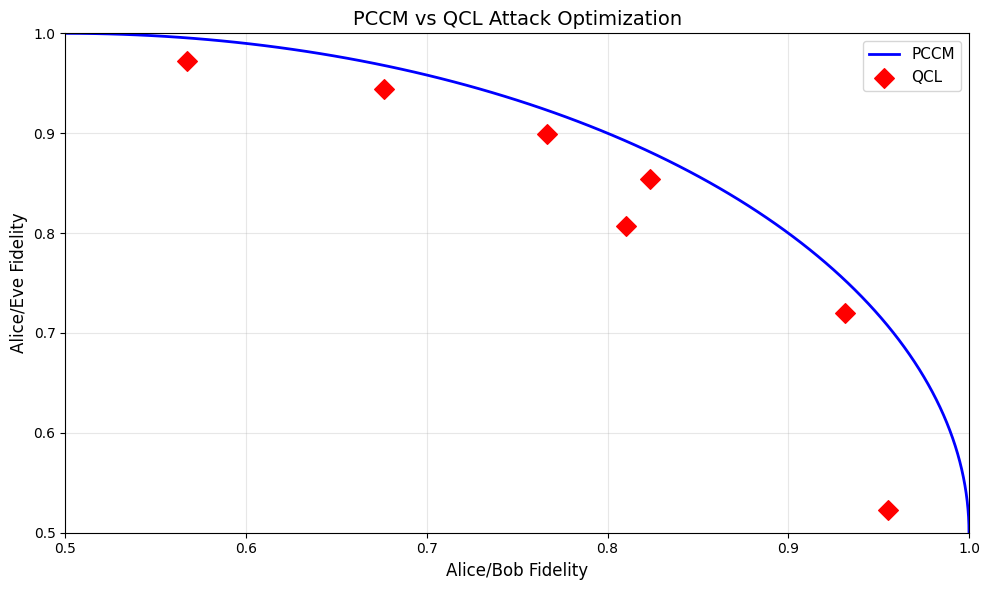

In [47]:
plot_pccm_vs_qcl(qcl_results)


In [ ]:
# @title
# Run without Cascade
res_no_eve = run_bb84(n=24, with_eve=False, with_cascade = False)

# Run with Cascade
res_with_eve = run_bb84(n=24, with_eve=False, with_cascade = False)

print('\nSummary:')
print(f"No Eve - sifted length: {len(res_no_eve['sifted_alice'])}, error rate: {res_no_eve['error_rate']:.3f}")
print(f"With Eve - sifted length: {len(res_with_eve['sifted_alice'])}, error rate: {res_with_eve['error_rate']:.3f}")

Bits flipped: 4
Alice bits:      [0, 1, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1]
Alice bases (0=Z,1=X): [0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0]
Bob bits:        [1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1]
Bob bases (0=Z,1=X):   [0, 1, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1]
Sifted indices (bases matched): [0, 1, 2, 4, 8, 9, 13, 14, 15, 19, 22]
Sifted Alice:    [0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0]
Sifted Bob:      [1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0]
Estimated error rate on sifted key: 0.182
Bits flipped: 4
Alice bits:      [0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0]
Alice bases (0=Z,1=X): [1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0]
Bob bits:        [0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 1]
Bob bases (0=Z,1=X):   [1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 1]
Sifted in

In [ ]:
# @title
# OPTIONAL - Using the sifted key for encryption/decryption
import binascii

def encrypt_message(unencrypted_string: str, key: str) -> str:
    # Convert ASCII string to binary string
    bits = bin(int(binascii.hexlify(unencrypted_string.encode("utf-8", "surrogatepass")), 16))[2:]
    bitstring = bits.zfill(8 * ((len(bits) + 7) // 8))
    # XOR with key
    encrypted_string = ""
    for i in range(len(bitstring)):
        encrypted_string += str(int(bitstring[i]) ^ int(key[i]))
    return encrypted_string

def decrypt_message(encrypted_bits: str, key: str) -> str:
    # XOR back with key
    unencrypted_bits = "".join(
        str(int(encrypted_bits[i]) ^ int(key[i]))
        for i in range(len(encrypted_bits))
    )

    # Convert to bytes
    i = int(unencrypted_bits, 2)
    hex_string = "%x" % i
    n = len(hex_string)
    raw_bytes = binascii.unhexlify(hex_string.zfill(n + (n & 1)))

    try:
        # Try decoding as UTF-8
        return raw_bytes.decode("utf-8", "surrogatepass")
    except UnicodeDecodeError:
        # Show corrupted output as hex and ASCII fallback
        hex_out = raw_bytes.hex()
        ascii_fallback = "".join(chr(b) if 32 <= b <= 126 else "?" for b in raw_bytes)
        return f"[Corrupted] ASCII≈'{ascii_fallback[:64]}...'"

def demonstrate_eve(secret_message="Quantum Computing is cool :)"):
    print("=== Without Eve ===")
    res_with_eve = run_bb84(n=64, with_eve=False, with_cascade=False, verbose=False)

    alice_key = "".join(str(b) for b in res_with_eve["sifted_alice"])
    bob_key   = "".join(str(b) for b in res_with_eve["sifted_bob"])

    needed_len = len(secret_message) * 8
    key_for_alice = (alice_key * ((needed_len // len(alice_key)) + 1))[:needed_len]
    key_for_bob   = (bob_key   * ((needed_len // len(bob_key)) + 1))[:needed_len]

    encrypted = encrypt_message(secret_message, key_for_alice)
    decrypted = decrypt_message(encrypted, key_for_bob)

    print("Error rate:", res_with_eve["error_rate"])
    print("Original:", secret_message)
    print("Decrypted by Bob:", decrypted)
    print()

    print("=== Without Cascade ===")
    res_no_eve = run_bb84(n=64, with_eve=True, with_cascade=False, verbose=False)

    alice_key = "".join(str(b) for b in res_no_eve["sifted_alice"])
    bob_key   = "".join(str(b) for b in res_no_eve["sifted_bob"])

    needed_len = len(secret_message) * 8
    key_for_alice = (alice_key * ((needed_len // len(alice_key)) + 1))[:needed_len]
    key_for_bob   = (bob_key   * ((needed_len // len(bob_key)) + 1))[:needed_len]

    encrypted = encrypt_message(secret_message, key_for_alice)
    decrypted = decrypt_message(encrypted, key_for_bob)

    print("Error rate:", res_no_eve["error_rate"])
    print("Original:", secret_message)
    print("Decrypted by Bob:", decrypted)
    print()

    print("=== With Cascade ===")
    res_with_eve = run_bb84(n=64, with_eve=True, with_cascade=True, verbose=False)

    alice_key = "".join(str(b) for b in res_with_eve["sifted_alice"])
    bob_key   = "".join(str(b) for b in res_with_eve["sifted_bob"])

    needed_len = len(secret_message) * 8
    key_for_alice = (alice_key * ((needed_len // len(alice_key)) + 1))[:needed_len]
    key_for_bob   = (bob_key   * ((needed_len // len(bob_key)) + 1))[:needed_len]

    encrypted = encrypt_message(secret_message, key_for_alice)
    decrypted = decrypt_message(encrypted, key_for_bob)

    print("Error rate:", res_with_eve["error_rate"])
    print("Original:", secret_message)
    print("Decrypted by Bob:", decrypted)


# Run the demonstration
demonstrate_eve()

=== Without Eve ===
Bits flipped: 11
Error rate: 0.20689655172413793
Original: Quantum Computing is cool :)
Decrypted by Bob: [Corrupted] ASCII≈'UT?fUy}aK??x6py,???c?g??d???...'

=== Without Cascade ===
Bits flipped: 10
Error rate: 0.3939393939393939
Original: Quantum Computing is cool :)
Decrypted by Bob: [Corrupted] ASCII≈'M?q??>es?J?Y???z???yH???XRbk...'

=== With Cascade ===
Bits flipped: 11
Error rate: 0.0
Original: Quantum Computing is cool :)
Decrypted by Bob: Quantum Computing is cool :)


In [48]:
# @title
def eve_intercept_with_pccm(alice_circuits, eve_bases, u_params, v_params,
                            n_qubits_u=2, n_layers_u=2, n_qubits_v=1, n_layers_v=1):
    forwarded = []
    eve_bits = []
    simulator = AerSimulator()

    for alice_qc, eve_basis in zip(alice_circuits, eve_bases):
        qc_attack = QuantumCircuit(n_qubits_u, 1)
        qc_attack.compose(alice_qc, qubits=[0], inplace=True)

        u_circuit = hardware_efficient_ansatz(n_qubits_u, n_layers_u, u_params)
        qc_attack.compose(u_circuit, inplace=True)

        if n_qubits_u > 1:
            if eve_basis == 1:
                qc_attack.h(1)
            qc_attack.measure(1, 0)

        compiled = transpile(qc_attack, simulator)
        result = simulator.run(compiled, shots=1).result()
        counts = result.get_counts()
        eve_bit = int(list(counts.keys())[0])
        eve_bits.append(eve_bit)

        qc_before_measure = QuantumCircuit(n_qubits_u)
        qc_before_measure.compose(alice_qc, qubits=[0], inplace=True)
        qc_before_measure.compose(u_circuit, inplace=True)

        statevec = Statevector.from_instruction(qc_before_measure)
        density_matrix = DensityMatrix(statevec)

        dm_bob = partial_trace(density_matrix, [1])

        rho = dm_bob.data
        prob_0 = np.real(rho[0, 0])
        prob_1 = np.real(rho[1, 1])

        total = prob_0 + prob_1
        if total > 1e-10:
            prob_0 /= total
            prob_1 /= total
        else:
            prob_0, prob_1 = 0.5, 0.5

        bob_qc = QuantumCircuit(1, 1)
        if np.random.random() < prob_1:
            bob_qc.x(0)

        forwarded.append(bob_qc)

    return forwarded, eve_bits

def run_bb84_with_pccm_attack(n=50, pccm_result=None, n_qubits_u=2, n_layers_u=2,
                              n_qubits_v=1, n_layers_v=1, verbose=True):
    if pccm_result is None:
        return {}

    u_params = pccm_result['u_params']
    v_params = pccm_result['v_params']

    if verbose:
        print(f"\nRunning BB84 with PCCM attack (n={n} qubits)")
        print(f"  F_AB target: {pccm_result['F_AB']:.4f}")
        print(f"  F_AE achieved: {pccm_result['F_AE']:.4f}")

    alice_bits = random_bits(n)
    alice_bases = random_bases(n)
    alice_circuits = prepare_circuits_for_alice(alice_bits, alice_bases)

    eve_bases = random_bases(n)
    forwarded_circuits, eve_bits = eve_intercept_with_pccm(
        alice_circuits, eve_bases, u_params, v_params, n_qubits_u, n_layers_u, n_qubits_v, n_layers_v
    )

    bob_bases = random_bases(n)
    bob_measure_circuits = measure_in_basis_circuits(bob_bases, forwarded_circuits)
    bob_bits = run_circuits_get_bits(bob_measure_circuits)

    sifted_alice, sifted_bob, sifted_indices = sift_key(alice_bits, alice_bases, bob_bits, bob_bases)
    sifted_eve = [eve_bits[i] for i in sifted_indices]

    qber = error_rate(sifted_alice, sifted_bob)
    eve_alice_error = error_rate(sifted_alice, sifted_eve)

    if verbose:
        print(f"  Sifted key length: {len(sifted_alice)}")
        print(f"  QBER: {qber:.4f}")
        print(f"  Eve's info gain: {1-eve_alice_error:.4f}")

    return {
        'qber': qber,
        'eve_information_gain': 1 - eve_alice_error,
        'sifted_alice': sifted_alice,
        'sifted_bob': sifted_bob,
        'sifted_eve': sifted_eve,
        'target_f_ab': pccm_result['F_AB'],
        'achieved_f_ae': pccm_result['F_AE']
    }

In [49]:
if __name__ == "__main__":
    print("\nStep 1: Optimizing PCCM attacks using QCL")
    print("-" * 70)

    print("\n" + "=" * 70)
    print("Step 2: Running PCCM Attack Simulations")
    print("-" * 70)

    sim_results = []
    for i, pccm in enumerate(qcl_results, 1):
        print(f"\n[Simulation {i}/{len(qcl_results)}]")
        result = run_bb84_with_pccm_attack(n=100, pccm_result=pccm, verbose=True)
        sim_results.append(result)

    print("\n" + "=" * 70)
    print("Step 3: Analysis Summary")
    print("=" * 70)
    print(f"\n{'F_AB':>8} {'F_AE':>8} {'QBER':>8} {'Eve Info':>10} {'Status':>15}")
    print("-" * 70)

    for r in sim_results:
        status = "✓ Stealthy" if r['qber'] <= 0.11 else "✗ Detectable"
        print(f"{r['target_f_ab']:8.4f} {r['achieved_f_ae']:8.4f} {r['qber']:8.4f} "
              f"{r['eve_information_gain']:10.4f} {status:>15}")

    print("\n" + "=" * 70)
    print("✓ Simulation complete!")
    print("\nFiles created:")
    print("  - qkd_pccm_simulation.py (reusable functions)")
    print("  - QKD_with_PCCM_Simulation.ipynb (complete notebook)")


Step 1: Optimizing PCCM attacks using QCL
----------------------------------------------------------------------

Step 2: Running PCCM Attack Simulations
----------------------------------------------------------------------

[Simulation 1/7]

Running BB84 with PCCM attack (n=100 qubits)
  F_AB target: 0.5674
  F_AE achieved: 0.9725
  Sifted key length: 49
  QBER: 0.4082
  Eve's info gain: 0.3878

[Simulation 2/7]

Running BB84 with PCCM attack (n=100 qubits)
  F_AB target: 0.6763
  F_AE achieved: 0.9441
  Sifted key length: 52
  QBER: 0.5000
  Eve's info gain: 0.4231

[Simulation 3/7]

Running BB84 with PCCM attack (n=100 qubits)
  F_AB target: 0.8104
  F_AE achieved: 0.8071
  Sifted key length: 46
  QBER: 0.1739
  Eve's info gain: 0.6739

[Simulation 4/7]

Running BB84 with PCCM attack (n=100 qubits)
  F_AB target: 0.7665
  F_AE achieved: 0.8991
  Sifted key length: 48
  QBER: 0.4167
  Eve's info gain: 0.4167

[Simulation 5/7]

Running BB84 with PCCM attack (n=100 qubits)
  F_AB tar